# TP optimisation — Exercice 2 : classification (réseau 3 couches)



In [1]:
import os
print("Dossier de travail (cwd) :", os.getcwd())

Dossier de travail (cwd) : c:\Users\lenovo\Desktop\HADRI


## 1. Configuration (modifiable)
Les fichiers de données doivent être dans `data/` (voir notebook `00_donnees`).

In [ ]:
from pathlib import Path
DATA_DIR = next((str(p) for p in [Path("data"), Path("../data")] if p.exists()), "data")
print("Données lues dans :", os.path.abspath(DATA_DIR))
IMAGES = [d for d, f in [("mnist", "mnist_50k_10k_10k.npz"), ("fashion", "fashion_mnist_50k_10k_10k.npz")] if os.path.exists(os.path.join(DATA_DIR, f))]
if len(IMAGES) < 2: print("ATTENTION : fichiers images manquants, jeux ignorés :", {"mnist", "fashion"} - set(IMAGES), "-> exécuter 00_donnees")

from types import SimpleNamespace
args = SimpleNamespace(data=DATA_DIR, out="results",
    datasets=["spiral", "iris"] + IMAGES,   
    epochs_csv=200,
    epochs_img=8,        
    fast=None)           

Données lues dans : c:\Users\lenovo\Desktop\HADRI\data


## 2. Code commun : les 7 optimiseurs (NumPy), vérification de gradient, utilitaires

In [ ]:
"""Outils communs aux 3 exercices : les 7 méthodes d'optimisation (NumPy pur),
vérification de gradient, chargement de données, tableaux LaTeX, ACP."""
import os, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

METHODS = ["GD", "GD+recherche", "SGD", "Momentum", "AdaGrad", "RMSprop", "Adam"]
COLORS = {"GD": "tab:blue", "GD+recherche": "tab:cyan", "SGD": "tab:orange",
          "Momentum": "tab:green", "AdaGrad": "tab:red", "RMSprop": "tab:purple",
          "Adam": "black", "Lloyd (réf.)": "tab:brown"}
FULL_BATCH = ("GD", "GD+recherche")          
MU = RHO = B1 = 0.9
B2 = 0.999
EPS = 1e-8
SEEDS = [42, 123, 2024]



def line_search_numeric(loss_fn, theta, g, eta_max, n=12):
    """Recherche directionnelle bornée et approchée : on teste eta_max/2^k
    (k=0..n-1) le long de -g et on garde le pas de plus petite perte."""
    best_eta, best = eta_max / 2 ** (n - 1), np.inf
    l0, calls, eta = loss_fn(theta), 1, eta_max
    best = l0
    found = False
    for _ in range(n):
        l = loss_fn(theta - eta * g)
        calls += 1
        if np.isfinite(l) and l < best:
            best, best_eta, found = l, eta, True
        eta /= 2
    return best_eta, calls


def run_optimizer(method, theta0, grad_fn, loss_fn, n, eta, epochs, batch_size, seed,
                  eval_fn, select_key, hvp=None, eta_max=5.0):
    """Boucle d'entraînement commune.
    grad_fn(theta, idx) et loss_fn(theta, idx=None) : idx=None <=> tout le jeu.
    eval_fn(theta) -> dict de métriques (contient select_key, à minimiser).
    hvp(g) : produit Hessienne-vecteur (pas exact pour les objectifs quadratiques)."""
    rng = np.random.default_rng(seed)
    theta = theta0.copy()
    m = np.zeros_like(theta); s = np.zeros_like(theta); v = np.zeros_like(theta)
    t = 0
    cnt = dict(updates=0, grad_calls=0, loss_calls=0, hvp_calls=0)
    hist, ttrain, diverged = [], 0.0, False
    best_val, best_theta, best_ep = np.inf, theta.copy(), 0
    with np.errstate(all="ignore"):
        for ep in range(1, epochs + 1):
            t0 = time.perf_counter()
            if method in FULL_BATCH:
                batches = [None]
            else:
                perm = rng.permutation(n)
                batches = [perm[i:i + batch_size] for i in range(0, n, batch_size)]
            for idx in batches:
                g = grad_fn(theta, idx); cnt["grad_calls"] += 1
                t += 1; cnt["updates"] += 1
                if method == "GD" or method == "SGD":
                    theta = theta - eta * g
                elif method == "GD+recherche":
                    step = None
                    if hvp is not None:
                        d = g @ hvp(g); cnt["hvp_calls"] += 1
                        if d > 0:
                            step = (g @ g) / d          
                    if step is None:
                        step, c = line_search_numeric(loss_fn, theta, g, eta_max)
                        cnt["loss_calls"] += c
                    theta = theta - step * g
                elif method == "Momentum":
                    v = MU * v + g
                    theta = theta - eta * v
                elif method == "AdaGrad":
                    s = s + g * g
                    theta = theta - eta * g / (np.sqrt(s) + EPS)
                elif method == "RMSprop":
                    s = RHO * s + (1 - RHO) * g * g
                    theta = theta - eta * g / (np.sqrt(s) + EPS)
                elif method == "Adam":
                    m = B1 * m + (1 - B1) * g
                    s = B2 * s + (1 - B2) * g * g
                    mh, sh = m / (1 - B1 ** t), s / (1 - B2 ** t)
                    theta = theta - eta * mh / (np.sqrt(sh) + EPS)
                else:
                    raise ValueError(method)
            ttrain += time.perf_counter() - t0        
            if not np.isfinite(theta).all():
                diverged = True
                break
            met = dict(eval_fn(theta))
            cnt["loss_calls"] += 2   
            met.update(epoch=ep, time=ttrain, updates=cnt["updates"],
                       grad_calls=cnt["grad_calls"], loss_calls=cnt["loss_calls"])
            hist.append(met)
            if met[select_key] < best_val:
                best_val, best_theta, best_ep = met[select_key], theta.copy(), ep
    return dict(hist=hist, best_value=(np.inf if diverged else best_val),
                best_theta=best_theta, best_epoch=best_ep, time=ttrain,
                diverged=diverged, **cnt)


def gradcheck(loss_fn, grad_fn, theta, ncoord=8, h=1e-5, seed=0):
    """Erreur relative max entre gradient analytique et différences finies
    centrales (h = 1e-5) sur quelques coordonnées (theta en float64)."""
    rng = np.random.default_rng(seed)
    g = grad_fn(theta, None)
    cand = np.where(np.abs(g) > 1e-3 * np.abs(g).max())[0]   
    cand = cand if len(cand) else np.arange(theta.size)  
    idxs = rng.choice(cand, min(ncoord, len(cand)), replace=False)
    errs = []
    for i in idxs:
        e = np.zeros_like(theta); e[i] = h
        num = (loss_fn(theta + e, None) - loss_fn(theta - e, None)) / (2 * h)
        errs.append(abs(num - g[i]) / max(1e-12, abs(num) + abs(g[i])))
    return float(max(errs))



def split_of(df):
    def f(v):
        v = str(v).lower()
        return "train" if v.startswith("tr") else ("val" if v.startswith("va") else "test")
    return df["split"].map(f).values


def find_col(df, candidates, default_last=True):
    for c in candidates:
        if c in df.columns:
            return c
    cols = [c for c in df.columns if c != "split"]
    return cols[-1] if default_last else None


def standardize(X, tr):
    mu, sd = X[tr].mean(0), X[tr].std(0)
    sd = np.where(sd == 0, 1.0, sd)
    return (X - mu) / sd, mu, sd


def pca2(X_fit, X_list):
    """ACP 2D par SVD (ajustée sur X_fit). Retourne les projections de X_list."""
    mu = X_fit.mean(0)
    _, _, Vt = np.linalg.svd(X_fit - mu, full_matrices=False)
    return [(X - mu) @ Vt[:2].T for X in X_list]


def ensure_dirs(out):
    os.makedirs(os.path.join(out, "figures"), exist_ok=True)


def savefig(fig, out, name):
    fig.tight_layout()
    fig.savefig(os.path.join(out, "figures", name + ".png"), dpi=130)
    plt.close(fig)


def ms(vals, dec=3):
    v = np.asarray(vals, float)
    return f"{v.mean():.{dec}f} $\\pm$ {v.std():.{dec}f}"


def tex_escape(s):
    s = str(s).replace("_", "\\_").replace("%", "\\%").replace("&", "\\&").replace("#", "\\#")
    for u, m in {"η": "$\\eta$", "λ": "$\\lambda$", "σ": "$\\sigma$", "τ": "$\\tau$"}.items():
        s = s.replace(u, m)
    return s


def df_to_latex(df, path):
    lines = ["\\resizebox{\\textwidth}{!}{%", "\\begin{tabular}{" + "l" * len(df.columns) + "}",
             "\\hline", " & ".join(tex_escape(c) for c in df.columns) + " \\\\", "\\hline"]
    for _, r in df.iterrows():
        lines.append(" & ".join(tex_escape(x) for x in r) + " \\\\")
    lines += ["\\hline", "\\end{tabular}}"]
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))


def load_npz_images(path, fast=None):
    d = np.load(path)
    out = {}
    for k in ["train", "val", "test"]:
        x = d["x_" + k].reshape(len(d["x_" + k]), -1)
        y = d["y_" + k].astype(np.int64).ravel()
        if fast and k == "train":
            x, y = x[:fast], y[:fast]
        out[k] = (x, y)
    return out

FASHION = ["T-shirt", "Pantalon", "Pull", "Robe", "Manteau", "Sandale",
           "Chemise", "Basket", "Sac", "Bottine"]

import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

## Définitions (modèles, gradients, données)

In [ ]:
"""Exercice 2 : classification multiclasse, réseau tanh à 3 couches entraînables."""
import os
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix)

ensure_dirs(args.out)
LAM = 1e-4
FILES = {"spiral": "classification_spiral3.csv", "iris": "classification_iris.csv",
         "mnist": "mnist_50k_10k_10k.npz", "fashion": "fashion_mnist_50k_10k_10k.npz"}
SIZES = {"spiral": [2, 32, 16, 3], "iris": [4, 32, 16, 3], "mnist": [784, 128, 64, 10], "fashion": [784, 128, 64, 10]}
GRIDS = {"GD": [0.03, 0.1, 0.3, 1.0], "SGD": [0.01, 0.03, 0.1, 0.3], "Momentum": [0.003, 0.01, 0.03, 0.1],
         "AdaGrad": [0.003, 0.01, 0.03, 0.1], "RMSprop": [3e-4, 1e-3, 3e-3, 1e-2],
         "Adam": [3e-4, 1e-3, 3e-3, 1e-2], "GD+recherche": [None]}


def init_net(sizes, seed, dtype):
    rng = np.random.default_rng(seed); parts = []
    for a, b in zip(sizes[:-1], sizes[1:]):
        parts += [rng.normal(0, np.sqrt(2 / (a + b)), (a, b)).ravel(), np.zeros(b)] 
    return np.concatenate(parts).astype(dtype)


def unpack(th, sizes):
    out, i = [], 0
    for a, b in zip(sizes[:-1], sizes[1:]):
        W = th[i:i + a * b].reshape(a, b); i += a * b
        out.append((W, th[i:i + b])); i += b
    return out


def forward(th, X, sizes):
    (W1, b1), (W2, b2), (W3, b3) = unpack(th, sizes)
    H1 = np.tanh(X @ W1 + b1); H2 = np.tanh(H1 @ W2 + b2)
    Z = H2 @ W3 + b3; Z = Z - Z.max(1, keepdims=True)          
    lse = np.log(np.exp(Z).sum(1, keepdims=True))
    return H1, H2, Z - lse                                      


def ce(th, X, y, sizes):
    logP = forward(th, X, sizes)[2]
    return float(-logP[np.arange(len(y)), y].mean())


def objective(th, X, y, idx, sizes, lam=LAM):
    if idx is not None: X, y = X[idx], y[idx]
    reg = sum((W ** 2).sum() for W, _ in unpack(th, sizes))
    return ce(th, X, y, sizes) + lam / 2 * float(reg)


def gradient(th, X, y, idx, sizes, lam=LAM):
    if idx is not None: X, y = X[idx], y[idx]
    (W1, _), (W2, _), (W3, _) = unpack(th, sizes)
    H1, H2, logP = forward(th, X, sizes); m = len(y)
    D3 = np.exp(logP); D3[np.arange(m), y] -= 1; D3 /= m            
    gW3, gb3 = H2.T @ D3 + lam * W3, D3.sum(0)
    D2 = (D3 @ W3.T) * (1 - H2 ** 2); gW2, gb2 = H1.T @ D2 + lam * W2, D2.sum(0)
    D1 = (D2 @ W2.T) * (1 - H1 ** 2); gW1, gb1 = X.T @ D1 + lam * W1, D1.sum(0)
    return np.concatenate([gW1.ravel(), gb1, gW2.ravel(), gb2, gW3.ravel(), gb3])


def predict(th, X, sizes, bs=10000):
    P = np.vstack([np.exp(forward(th, X[i:i + bs], sizes)[2]) for i in range(0, len(X), bs)])
    return P.argmax(1), P


def load(name):
    path = os.path.join(args.data, FILES[name])
    if name in ("spiral", "iris"):
        df = pd.read_csv(path); sp = split_of(df)
        lc = find_col(df, ["label", "y", "target", "class"])
        feats = [c for c in df.columns if c not in (lc, "split")]
        X = df[feats].values.astype(float); cl = np.unique(df[lc].values)
        y = np.searchsorted(cl, df[lc].values)
        Xs, _, _ = standardize(X, sp == "train")
        return {k: (Xs[sp == k], y[sp == k]) for k in ["train", "val", "test"]}, {k: X[sp == k] for k in ["train", "val", "test"]}, np.float64
    d = load_npz_images(path, args.fast)
    mean = (d["train"][0].astype(np.float32) / 255).mean(0)
    D = {k: ((d[k][0].astype(np.float32) / 255 - mean).astype(np.float32), d[k][1]) for k in d}
    raw = {k: d[k][0].astype(np.float32) / 255 for k in d}
    return D, raw, np.float32


def metr(y, pred, P):
    pr, rc, f1, _ = precision_recall_fscore_support(y, pred, average="macro", zero_division=0)
    return dict(acc=accuracy_score(y, pred), prec=pr, rec=rc, f1=f1,
                ce=float(-np.log(np.maximum(P[np.arange(len(y)), y], 1e-300)).mean()))

## Entraînement, évaluation et figures (par jeu de données)

In [ ]:
rows, gc_rows = [], []
for name in args.datasets:
    D, RAW, dt = load(name); sizes = SIZES[name]
    (Xtr, ytr), (Xva, yva), (Xte, yte) = D["train"], D["val"], D["test"]
    img = name in ("mnist", "fashion")
    epochs, bs = (args.epochs_img, 1024) if img else (args.epochs_csv, 32)
    sub = slice(0, 64); Xg, yg = Xtr[sub].astype(float), ytr[sub]
    thg = init_net(sizes, 0, np.float64) + np.random.default_rng(1).normal(0, 0.05, sum(a * b + b for a, b in zip(sizes[:-1], sizes[1:])))
    gc_rows.append(dict(jeu=name, err_rel_max=f"{gradcheck(lambda t, i: objective(t, Xg, yg, i, sizes), lambda t, i: gradient(t, Xg, yg, i, sizes), thg, ncoord=20):.2e}"))
    print(name, "gradcheck", gc_rows[-1]["err_rel_max"], flush=True)

    def ev(th):
        _, Ptr = predict(th, Xtr, sizes); _, Pva = predict(th, Xva, sizes)
        return dict(train_loss=ce(th, Xtr, ytr, sizes), val_loss=ce(th, Xva, yva, sizes),
                    train_acc=float((Ptr.argmax(1) == ytr).mean()), val_acc=float((Pva.argmax(1) == yva).mean()))

    def run(method, eta, seed):
        th0 = init_net(sizes, seed, dt)                       
        return run_optimizer(method, th0, lambda th, i: gradient(th, Xtr, ytr, i, sizes),
                             lambda th, i=None: objective(th, Xtr, ytr, i, sizes), len(ytr),
                             eta, epochs, bs, seed, ev, "val_loss", eta_max=5.0)
    HIST, THETA = {}, {}
    for method in METHODS:
        pilot = {eta: run(method, eta, 42) for eta in GRIDS[method]}    
        eta = min(pilot, key=lambda e: pilot[e]["best_value"])
        for seed in SEEDS:
            r = pilot[eta] if seed == 42 else run(method, eta, seed)
            if seed == 42: HIST[method], THETA[method] = r["hist"], r["best_theta"]
            pred, P = predict(r["best_theta"], Xte, sizes)
            rows.append(dict(jeu=name, méthode=method, seed=seed, eta=eta if eta else np.nan, val_loss=r["best_value"],
                             best_epoch=r["best_epoch"], temps=r["time"], updates=r["updates"],
                             grad_calls=r["grad_calls"], loss_calls=r["loss_calls"], diverge=r["diverged"], **metr(yte, pred, P)))
        print(name, method, "eta=", eta, flush=True)

    R = pd.DataFrame([r for r in rows if r["jeu"] == name])
    R.to_csv(os.path.join(args.out, f"ex2_{name}_resultats_bruts.csv"), index=False)
    T = []
    for me, g in R.groupby("méthode", sort=False):
        T.append({"méthode": me, "η": "auto" if np.isnan(g.eta.iloc[0]) else f"{g.eta.iloc[0]:.1e}",
                  "exactitude": ms(g.acc), "préc. macro": ms(g.prec), "rappel macro": ms(g.rec), "F1 macro": ms(g.f1),
                  "CE test": ms(g.ce), "perte val": ms(g.val_loss), "meill. époque": f"{g.best_epoch.mean():.0f}",
                  "temps (s)": ms(g.temps, 1), "mises à jour": f"{g.updates.mean():.0f}",
                  "appels grad": f"{g.grad_calls.mean():.0f}", "appels objectif": f"{g.loss_calls.mean():.0f}"})
    pd.DataFrame(T).to_csv(os.path.join(args.out, f"ex2_table_{name}.csv"), index=False)
    df_to_latex(pd.DataFrame(T), os.path.join(args.out, f"tab_ex2_{name}.tex"))

    fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
    for me in METHODS:
        h = HIST[me]
        if not h: continue
        ep = [x["epoch"] for x in h]
        ax[0].plot(ep, [x["train_loss"] for x in h], color=COLORS[me], label=me)
        ax[0].plot(ep, [x["val_loss"] for x in h], "--", color=COLORS[me])
        ax[1].plot(ep, [x["train_acc"] for x in h], color=COLORS[me], label=me)
        ax[1].plot(ep, [x["val_acc"] for x in h], "--", color=COLORS[me])
        ax[2].plot([x["time"] for x in h], [x["val_loss"] for x in h], color=COLORS[me], label=me)
    ax[0].set_title("Entropie croisée (trait plein : train, tirets : validation)"); ax[0].set_xlabel("époque"); ax[0].set_yscale("log")
    ax[1].set_title("Exactitude (plein : train, tirets : validation)"); ax[1].set_xlabel("époque")
    ax[2].set_title("Perte de validation vs temps"); ax[2].set_xlabel("temps d'entraînement (s)"); ax[2].set_yscale("log")
    ax[1].legend(fontsize=7); fig.suptitle(f"Ex.2 – {name} : courbes d'apprentissage (graine 42)")
    savefig(fig, args.out, f"ex2_{name}_curves")

    best = R[~R.diverge].groupby("méthode").val_loss.mean().idxmin()       
    th = THETA[best]; pred, P = predict(th, Xte, sizes); C = confusion_matrix(yte, pred)
    labels = FASHION if name == "fashion" else list(range(len(C)))
    fig, a_ = plt.subplots(figsize=(8.5, 7.5) if img else (5.5, 5))
    im = a_.imshow(C, cmap="Blues"); fig.colorbar(im, label="effectif")
    a_.set_xticks(range(len(C))); a_.set_yticks(range(len(C)))
    a_.set_xticklabels(labels, rotation=60 if name == "fashion" else 0); a_.set_yticklabels(labels)
    for i in range(len(C)):
        for j in range(len(C)):
            a_.text(j, i, C[i, j], ha="center", va="center", fontsize=8 if img else 11, color="white" if C[i, j] > C.max() / 2 else "black")
    a_.set_xlabel("prédit"); a_.set_ylabel("réel"); a_.set_title(f"Ex.2 – {name}, {best} : matrice de confusion (test, graine 42)")
    savefig(fig, args.out, f"ex2_{name}_confusion")
    _, _, f1c, _ = precision_recall_fscore_support(yte, pred, zero_division=0)
    fig, a_ = plt.subplots(figsize=(7, 4)); a_.bar([str(l) for l in labels], f1c)
    a_.set_xlabel("classe"); a_.set_ylabel("F1"); a_.set_title(f"Ex.2 – {name}, {best} : F1 par classe (test)")
    if name == "fashion": a_.tick_params(axis="x", rotation=60)
    savefig(fig, args.out, f"ex2_{name}_f1")

    if name == "spiral":
        g = np.linspace(Xtr[:, 0].min() - .5, Xtr[:, 0].max() + .5, 250), np.linspace(Xtr[:, 1].min() - .5, Xtr[:, 1].max() + .5, 250)
        XX, YY = np.meshgrid(*g); Z = predict(th, np.c_[XX.ravel(), YY.ravel()], sizes)[0].reshape(XX.shape)
        fig, a_ = plt.subplots(figsize=(6.5, 6)); a_.contourf(XX, YY, Z, alpha=0.3, cmap="viridis")
        a_.scatter(Xte[:, 0], Xte[:, 1], c=yte, cmap="viridis", edgecolor="k"); a_.set_xlabel("x1 (standardisée)"); a_.set_ylabel("x2 (standardisée)")
        a_.set_title(f"Ex.2 – spirales, {best} : frontière de décision (points = test)")
        savefig(fig, args.out, "ex2_spiral_boundary")
    if name == "iris":
        Ptr_, Pte_ = pca2(Xtr, [Xtr, Xte]); fig, a_ = plt.subplots(figsize=(6.5, 5.5))
        sc = a_.scatter(Pte_[:, 0], Pte_[:, 1], c=yte, cmap="viridis", s=60, edgecolor="k")
        bad = pred != yte; a_.scatter(Pte_[bad, 0], Pte_[bad, 1], marker="x", c="red", s=120, label="mal classé")
        a_.legend(*sc.legend_elements(), title="classe réelle", loc="upper left"); a_.add_artist(a_.legend(loc="lower right"))
        a_.set_xlabel("ACP 1"); a_.set_ylabel("ACP 2"); a_.set_title(f"Ex.2 – Iris, {best} : projection ACP 2D (test)")
        savefig(fig, args.out, "ex2_iris_pca")
    if img:
        conf = P.max(1); good = np.where(pred == yte)[0][:6]; badi = np.where(pred != yte)[0][:6]
        fig, ax = plt.subplots(2, 6, figsize=(15, 6))
        for r_, ids, tt in [(0, good, "bien classé"), (1, badi, "mal classé")]:
            for c_ in range(6):
                a_ = ax[r_, c_]; a_.axis("off")
                if c_ < len(ids):
                    i = ids[c_]; a_.imshow(RAW["test"][i].reshape(28, 28), cmap="gray")
                    a_.set_title(f"{tt}\nréel {labels[yte[i]]} / prédit {labels[pred[i]]}\nconfiance {conf[i]:.2f}", fontsize=9)
        fig.suptitle(f"Ex.2 – {name}, {best} : exemples du test officiel (graine 42)")
        savefig(fig, args.out, f"ex2_{name}_examples")

pd.DataFrame(gc_rows).to_csv(os.path.join(args.out, "ex2_gradcheck.csv"), index=False)
df_to_latex(pd.DataFrame(gc_rows), os.path.join(args.out, "tab_gradcheck_ex2.tex"))
print("Exercice 2 terminé.")

spiral gradcheck 4.94e-10
spiral GD eta= 1.0
spiral GD+recherche eta= None
spiral SGD eta= 0.3
spiral Momentum eta= 0.1
spiral AdaGrad eta= 0.1
spiral RMSprop eta= 0.01
spiral Adam eta= 0.01
iris gradcheck 1.94e-09
iris GD eta= 1.0
iris GD+recherche eta= None
iris SGD eta= 0.3
iris Momentum eta= 0.03
iris AdaGrad eta= 0.1
iris RMSprop eta= 0.01
iris Adam eta= 0.01
mnist gradcheck 1.55e-08
mnist GD eta= 1.0
mnist GD+recherche eta= None
mnist SGD eta= 0.3
mnist Momentum eta= 0.1
mnist AdaGrad eta= 0.1
mnist RMSprop eta= 0.003
mnist Adam eta= 0.01
fashion gradcheck 9.70e-08
fashion GD eta= 1.0
fashion GD+recherche eta= None
fashion SGD eta= 0.3
fashion Momentum eta= 0.1
fashion AdaGrad eta= 0.03
fashion RMSprop eta= 0.003
fashion Adam eta= 0.003
Exercice 2 terminé.


## Résultats : tableaux

In [ ]:
import glob
from IPython.display import display
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
for f in sorted(glob.glob("results/ex2_table_*.csv")):
    print(f); display(pd.read_csv(f))
print("Gradcheck :"); display(pd.read_csv("results/ex2_gradcheck.csv"))

results\ex2_table_fashion.csv


,méthode,η,exactitude,préc. macro,rappel macro,F1 macro,CE test,perte val,meill. époque,temps (s),mises à jour,appels grad,appels objectif
0,GD,1.0e+00,0.692 $\pm$ 0.004,0.715 $\pm$ 0.006,0.692 $\pm$ 0.004,0.666 $\pm$ 0.010,0.822 $\pm$ 0.022,0.805 $\pm$ 0.022,8,3.4 $\pm$ 0.1,8,8,16
1,GD+recherche,auto,0.747 $\pm$ 0.010,0.744 $\pm$ 0.011,0.747 $\pm$ 0.010,0.741 $\pm$ 0.011,0.750 $\pm$ 0.048,0.733 $\pm$ 0.052,8,24.8 $\pm$ 1.6,8,8,120
2,SGD,3.0e-01,0.848 $\pm$ 0.003,0.847 $\pm$ 0.002,0.848 $\pm$ 0.003,0.847 $\pm$ 0.002,0.422 $\pm$ 0.005,0.388 $\pm$ 0.004,8,4.5 $\pm$ 0.3,392,392,16
3,Momentum,1.0e-01,0.867 $\pm$ 0.002,0.867 $\pm$ 0.001,0.867 $\pm$ 0.002,0.867 $\pm$ 0.002,0.373 $\pm$ 0.004,0.339 $\pm$ 0.004,8,4.6 $\pm$ 0.3,392,392,16
4,AdaGrad,3.0e-02,0.871 $\pm$ 0.003,0.870 $\pm$ 0.003,0.871 $\pm$ 0.003,0.870 $\pm$ 0.003,0.364 $\pm$ 0.006,0.333 $\pm$ 0.003,7,4.5 $\pm$ 0.3,392,392,16
5,RMSprop,3.0e-03,0.868 $\pm$ 0.001,0.869 $\pm$ 0.001,0.868 $\pm$ 0.001,0.867 $\pm$ 0.001,0.364 $\pm$ 0.002,0.336 $\pm$ 0.001,7,4.4 $\pm$ 0.2,392,392,16
6,Adam,3.0e-03,0.878 $\pm$ 0.002,0.878 $\pm$ 0.001,0.878 $\pm$ 0.002,0.877 $\pm$ 0.002,0.347 $\pm$ 0.002,0.318 $\pm$ 0.004,8,4.6 $\pm$ 0.0,392,392,16


results\ex2_table_iris.csv


,méthode,η,exactitude,préc. macro,rappel macro,F1 macro,CE test,perte val,meill. époque,temps (s),mises à jour,appels grad,appels objectif
0,GD,1.0e+00,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,0.024 $\pm$ 0.002,0.091 $\pm$ 0.009,164,0.1 $\pm$ 0.0,200,200,400
1,GD+recherche,auto,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,0.020 $\pm$ 0.001,0.091 $\pm$ 0.005,106,0.8 $\pm$ 0.1,200,200,3000
2,SGD,3.0e-01,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,0.027 $\pm$ 0.004,0.082 $\pm$ 0.005,144,0.2 $\pm$ 0.0,600,600,400
3,Momentum,3.0e-02,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,0.023 $\pm$ 0.002,0.088 $\pm$ 0.009,137,0.1 $\pm$ 0.0,600,600,400
4,AdaGrad,1.0e-01,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,0.031 $\pm$ 0.004,0.082 $\pm$ 0.004,89,0.1 $\pm$ 0.0,600,600,400
5,RMSprop,1.0e-02,0.989 $\pm$ 0.016,0.990 $\pm$ 0.014,0.989 $\pm$ 0.016,0.989 $\pm$ 0.016,0.035 $\pm$ 0.006,0.066 $\pm$ 0.008,125,0.1 $\pm$ 0.0,600,600,400
6,Adam,1.0e-02,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,0.023 $\pm$ 0.001,0.085 $\pm$ 0.009,68,0.1 $\pm$ 0.0,600,600,400


results\ex2_table_mnist.csv


,méthode,η,exactitude,préc. macro,rappel macro,F1 macro,CE test,perte val,meill. époque,temps (s),mises à jour,appels grad,appels objectif
0,GD,1.0e+00,0.880 $\pm$ 0.001,0.879 $\pm$ 0.001,0.878 $\pm$ 0.001,0.878 $\pm$ 0.001,0.473 $\pm$ 0.007,0.491 $\pm$ 0.008,8,3.8 $\pm$ 0.2,8,8,16
1,GD+recherche,auto,0.868 $\pm$ 0.005,0.874 $\pm$ 0.004,0.866 $\pm$ 0.005,0.865 $\pm$ 0.004,0.450 $\pm$ 0.017,0.465 $\pm$ 0.018,8,24.9 $\pm$ 0.7,8,8,120
2,SGD,3.0e-01,0.938 $\pm$ 0.001,0.937 $\pm$ 0.001,0.937 $\pm$ 0.001,0.937 $\pm$ 0.001,0.215 $\pm$ 0.003,0.213 $\pm$ 0.004,8,4.7 $\pm$ 0.2,392,392,16
3,Momentum,1.0e-01,0.961 $\pm$ 0.000,0.960 $\pm$ 0.000,0.960 $\pm$ 0.000,0.960 $\pm$ 0.000,0.132 $\pm$ 0.003,0.129 $\pm$ 0.001,8,4.4 $\pm$ 0.4,392,392,16
4,AdaGrad,1.0e-01,0.969 $\pm$ 0.000,0.969 $\pm$ 0.000,0.969 $\pm$ 0.000,0.969 $\pm$ 0.000,0.103 $\pm$ 0.000,0.097 $\pm$ 0.003,7,4.1 $\pm$ 0.1,392,392,16
5,RMSprop,3.0e-03,0.970 $\pm$ 0.001,0.970 $\pm$ 0.001,0.970 $\pm$ 0.001,0.970 $\pm$ 0.001,0.099 $\pm$ 0.002,0.096 $\pm$ 0.000,8,4.1 $\pm$ 0.1,392,392,16
6,Adam,1.0e-02,0.969 $\pm$ 0.001,0.968 $\pm$ 0.001,0.968 $\pm$ 0.001,0.968 $\pm$ 0.001,0.107 $\pm$ 0.005,0.099 $\pm$ 0.003,7,4.6 $\pm$ 0.2,392,392,16


results\ex2_table_spiral.csv


,méthode,η,exactitude,préc. macro,rappel macro,F1 macro,CE test,perte val,meill. époque,temps (s),mises à jour,appels grad,appels objectif
0,GD,1.0e+00,0.993 $\pm$ 0.005,0.993 $\pm$ 0.005,0.993 $\pm$ 0.005,0.993 $\pm$ 0.005,0.016 $\pm$ 0.005,0.021 $\pm$ 0.001,200,0.1 $\pm$ 0.0,200,200,400
1,GD+recherche,auto,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,0.006 $\pm$ 0.002,0.010 $\pm$ 0.000,200,1.2 $\pm$ 0.0,200,200,3000
2,SGD,3.0e-01,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,0.005 $\pm$ 0.002,0.009 $\pm$ 0.001,191,0.4 $\pm$ 0.0,1800,1800,400
3,Momentum,1.0e-01,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,0.003 $\pm$ 0.001,0.008 $\pm$ 0.003,194,0.6 $\pm$ 0.0,1800,1800,400
4,AdaGrad,1.0e-01,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,0.008 $\pm$ 0.000,0.012 $\pm$ 0.003,190,0.7 $\pm$ 0.0,1800,1800,400
5,RMSprop,1.0e-02,0.996 $\pm$ 0.005,0.996 $\pm$ 0.005,0.996 $\pm$ 0.005,0.996 $\pm$ 0.005,0.008 $\pm$ 0.007,0.002 $\pm$ 0.000,152,0.8 $\pm$ 0.0,1800,1800,400
6,Adam,1.0e-02,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,1.000 $\pm$ 0.000,0.004 $\pm$ 0.002,0.007 $\pm$ 0.002,183,0.7 $\pm$ 0.1,1800,1800,400


Gradcheck :


,jeu,err_rel_max
0,spiral,4.940000e-10
1,iris,1.940000e-09
2,mnist,1.550000e-08
3,fashion,9.700000e-08


## Résultats : figures

results/figures\ex2_fashion_confusion.png


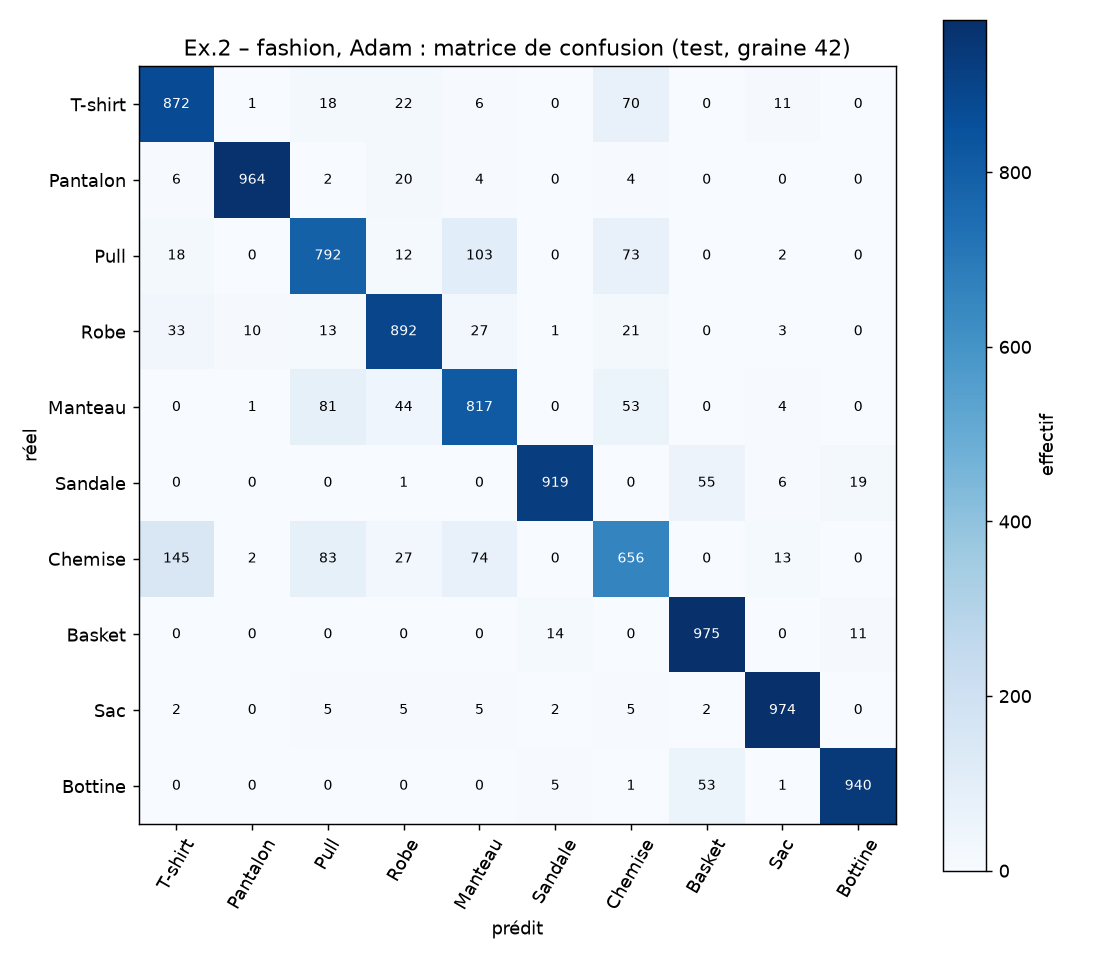

results/figures\ex2_fashion_curves.png


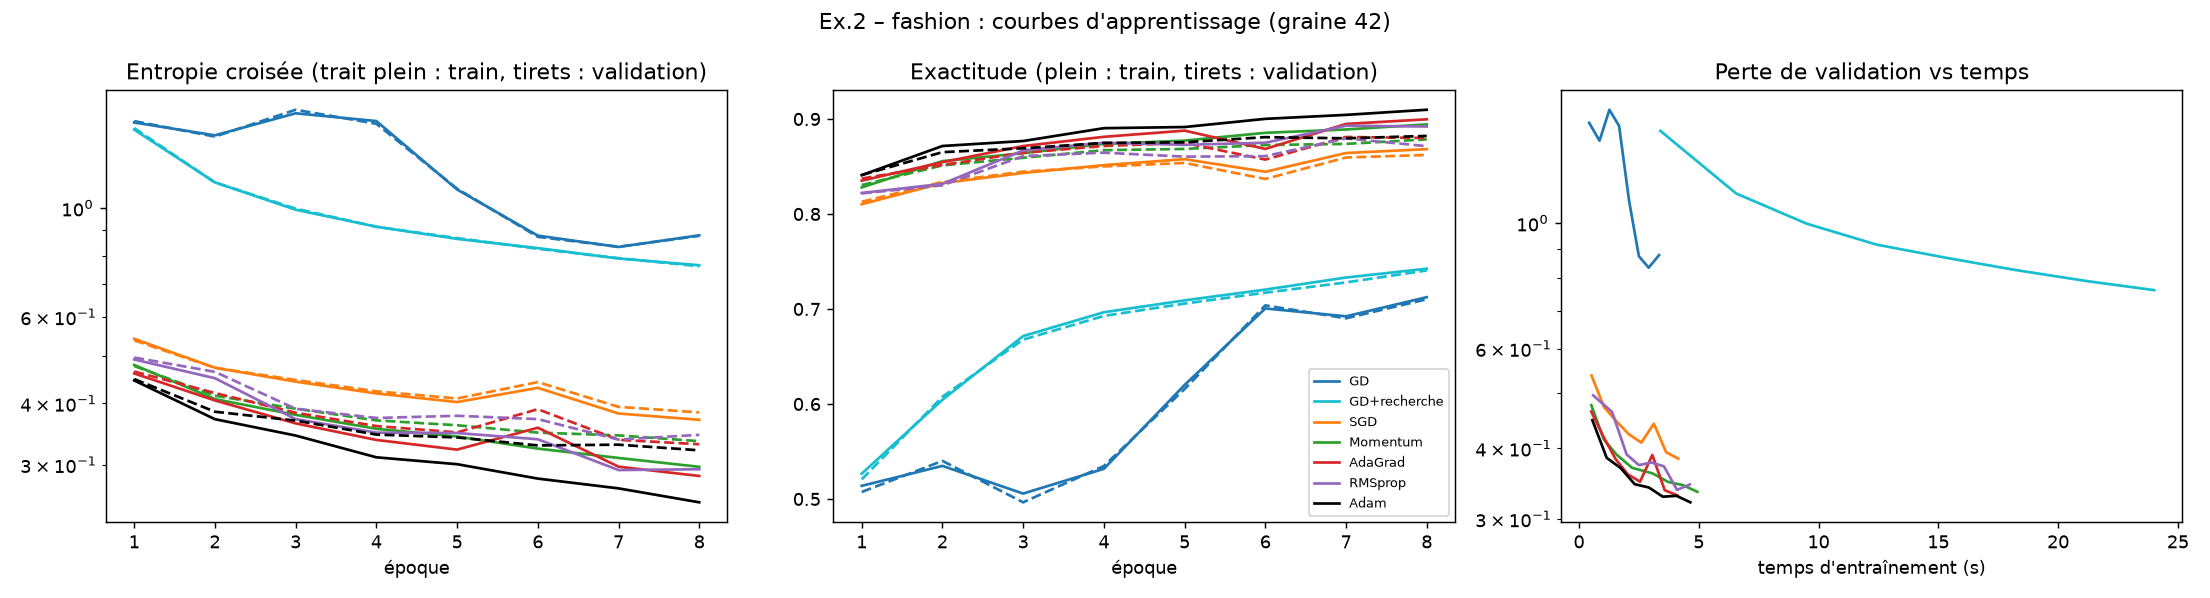

results/figures\ex2_fashion_examples.png


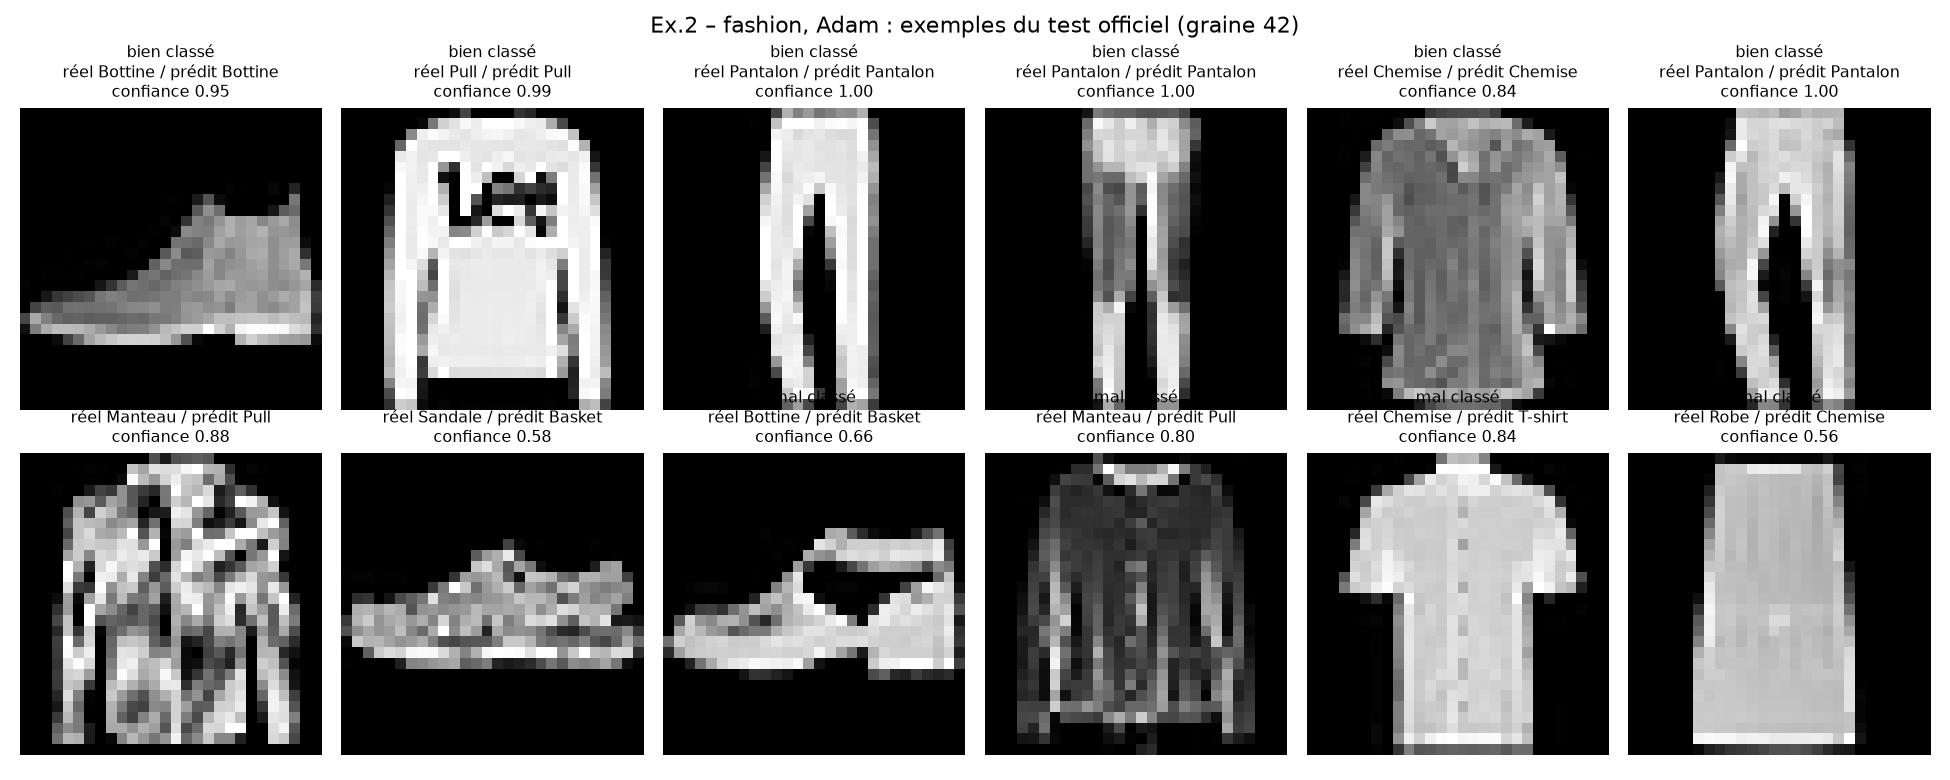

results/figures\ex2_fashion_f1.png


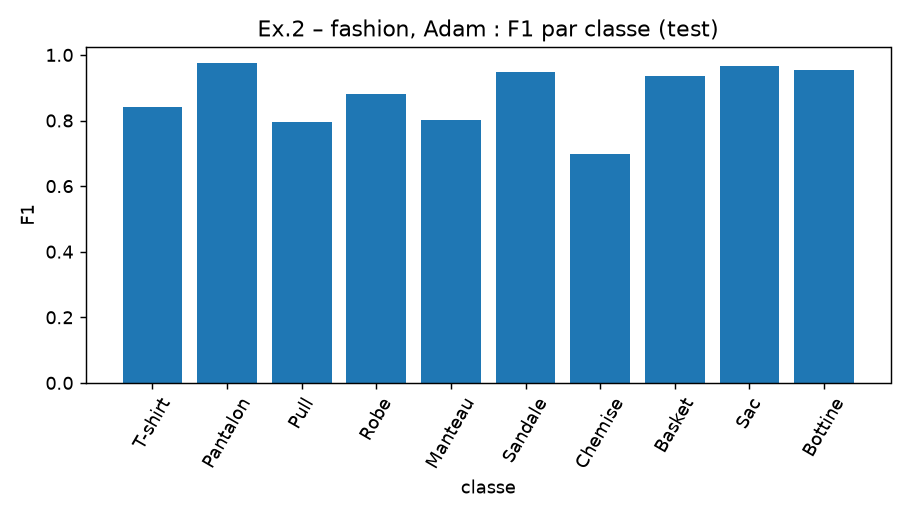

results/figures\ex2_iris_confusion.png


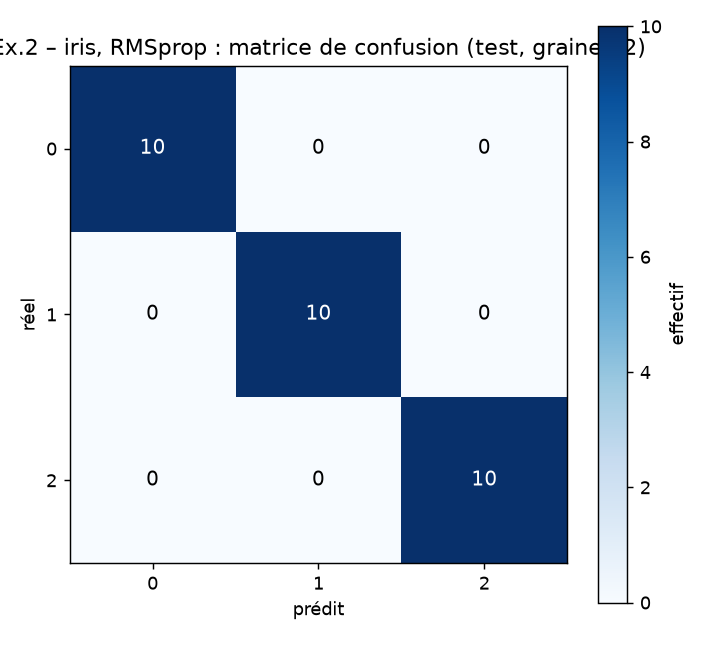

results/figures\ex2_iris_curves.png


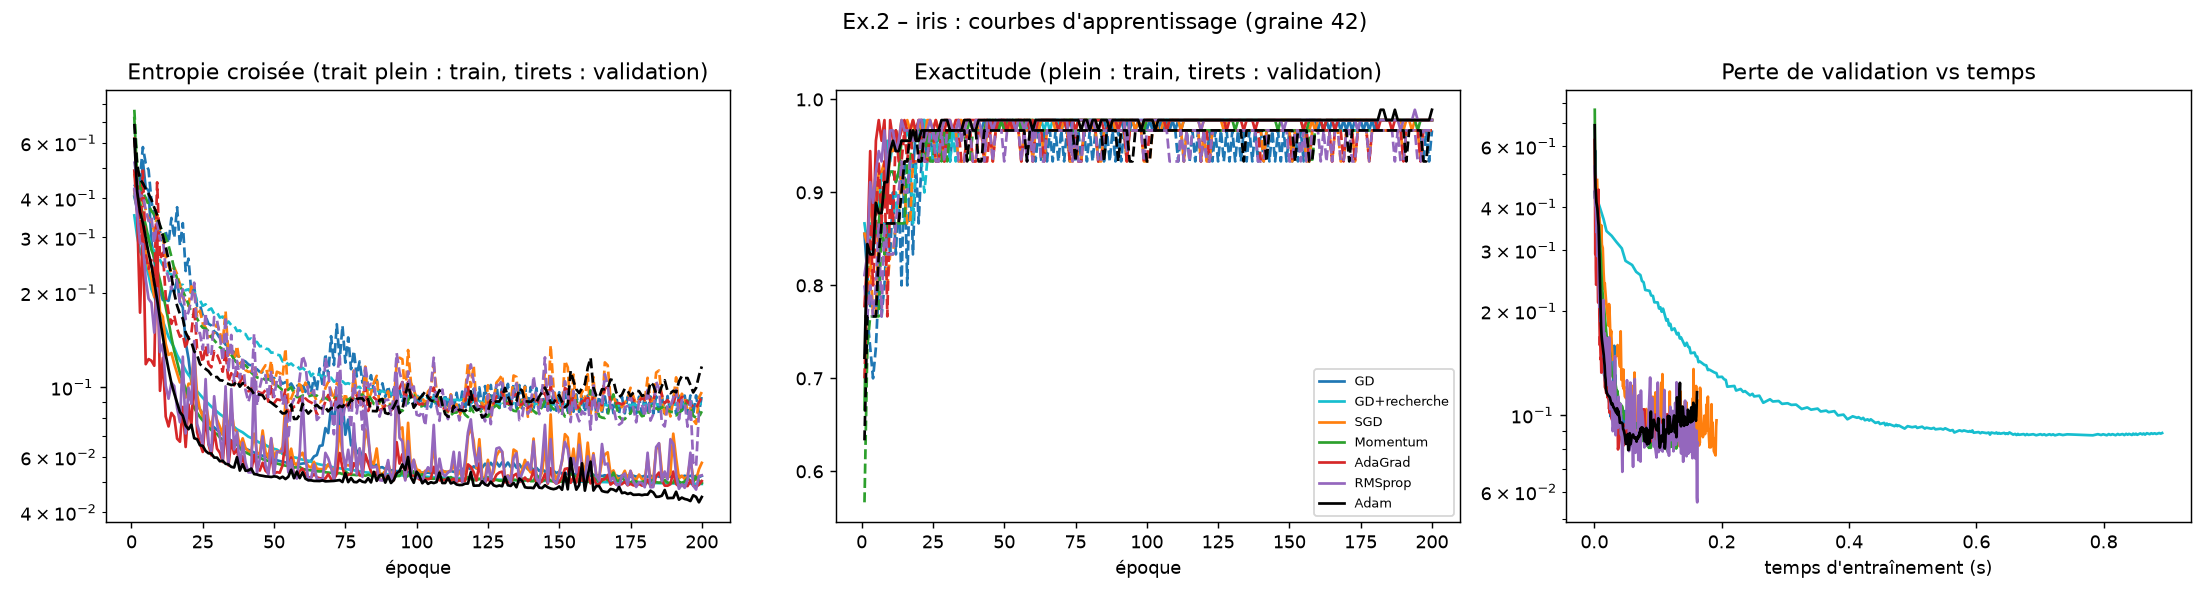

results/figures\ex2_iris_f1.png


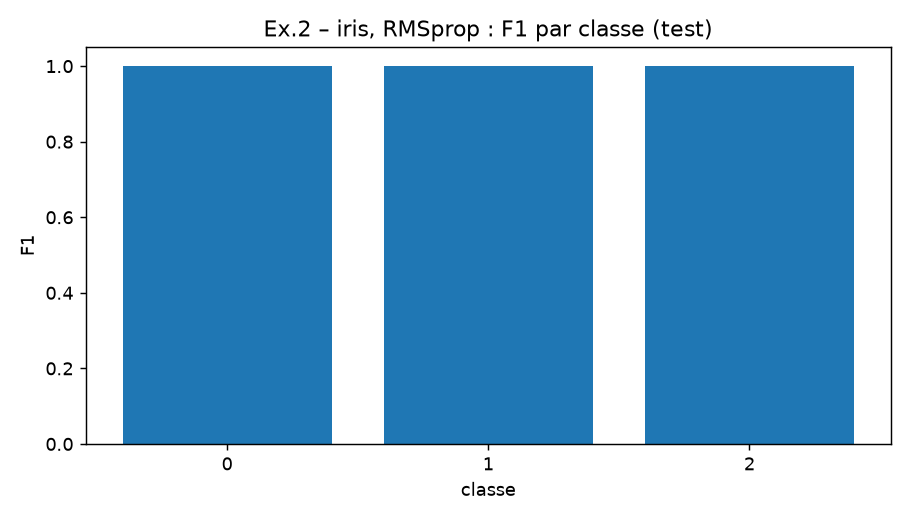

results/figures\ex2_iris_pca.png


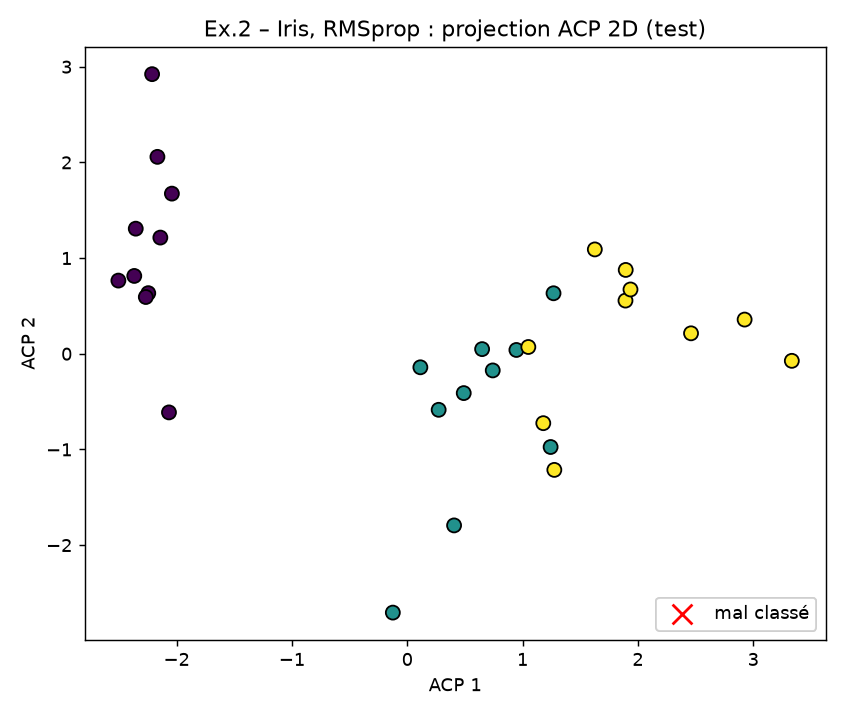

results/figures\ex2_mnist_confusion.png


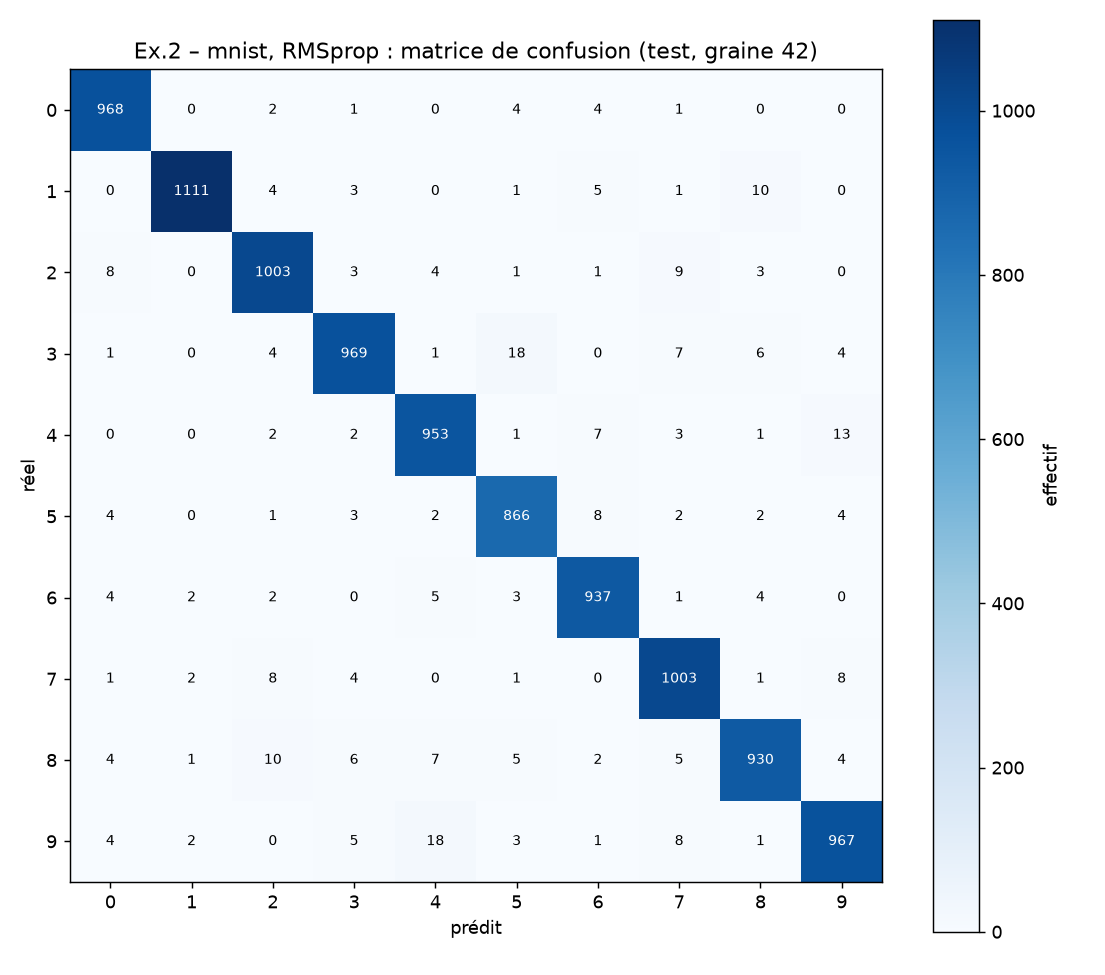

results/figures\ex2_mnist_curves.png


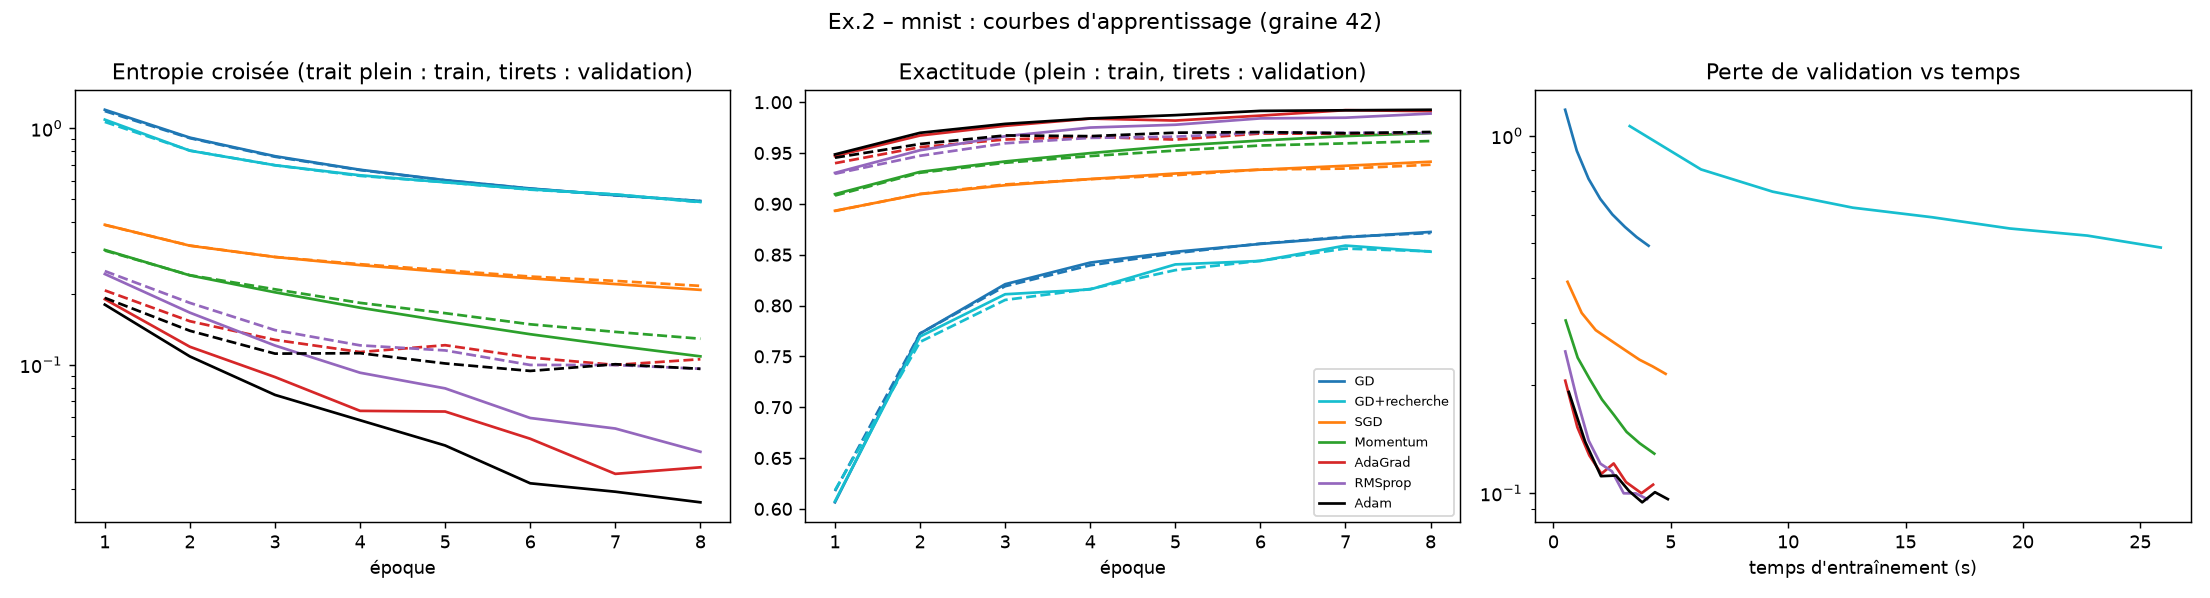

results/figures\ex2_mnist_examples.png


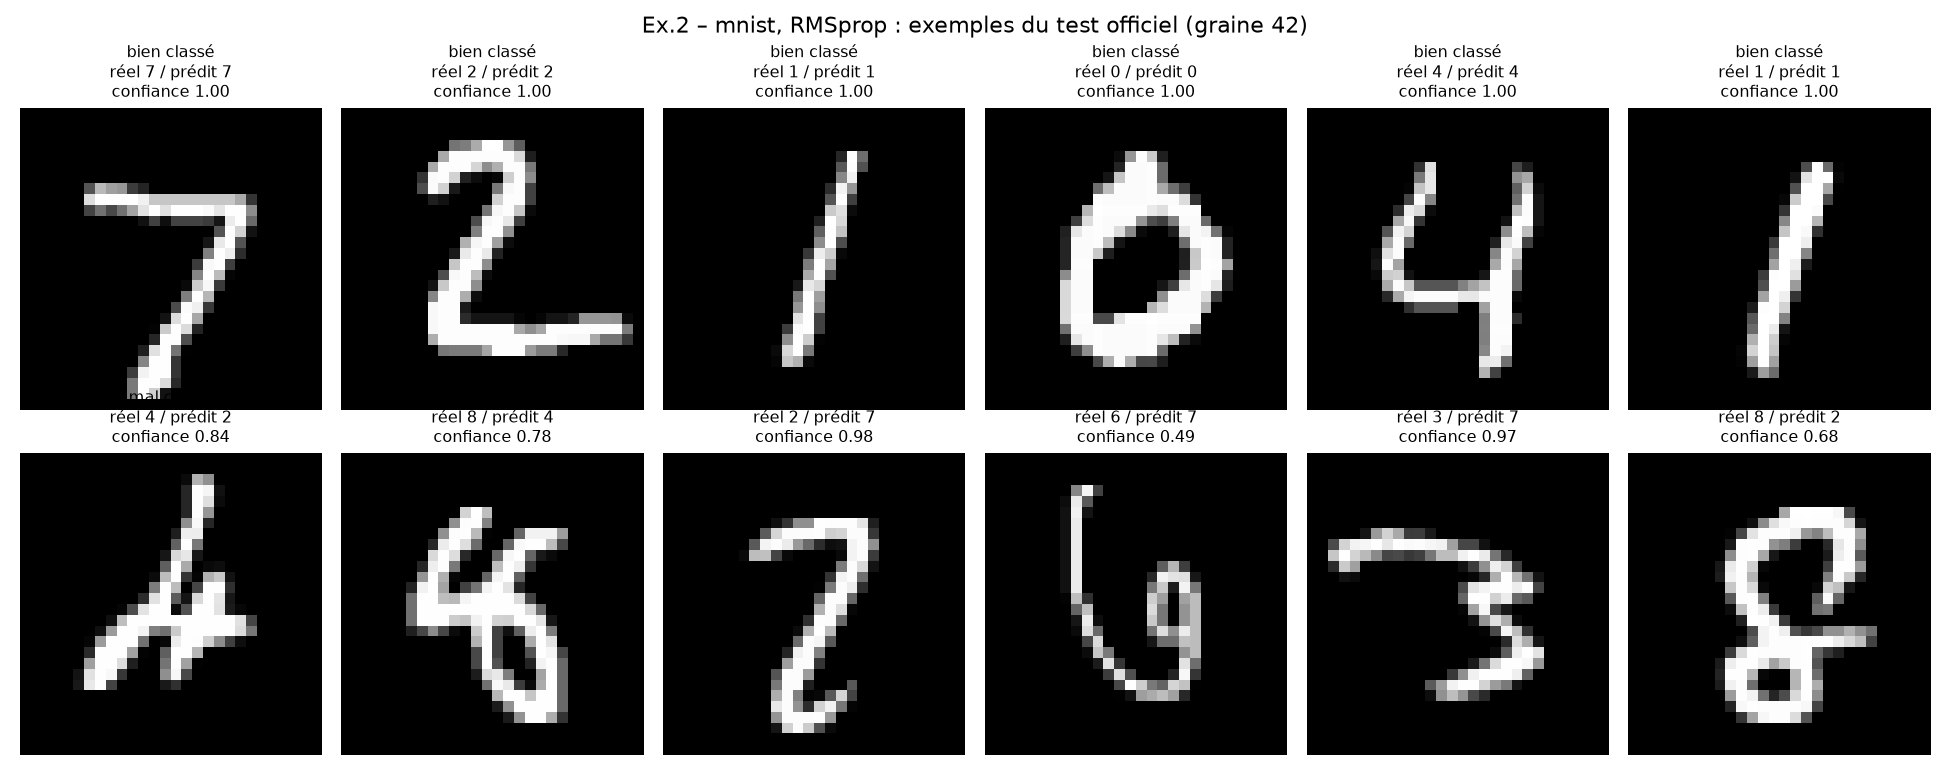

results/figures\ex2_mnist_f1.png


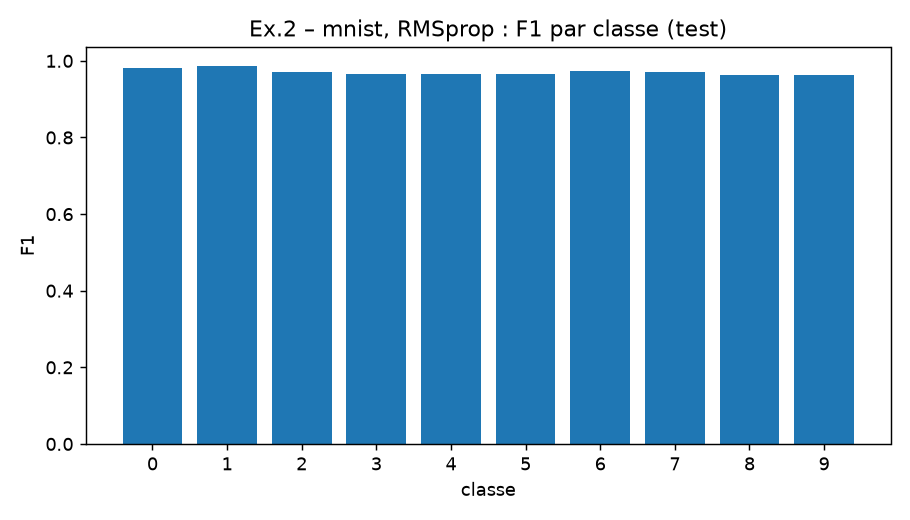

results/figures\ex2_spiral_boundary.png


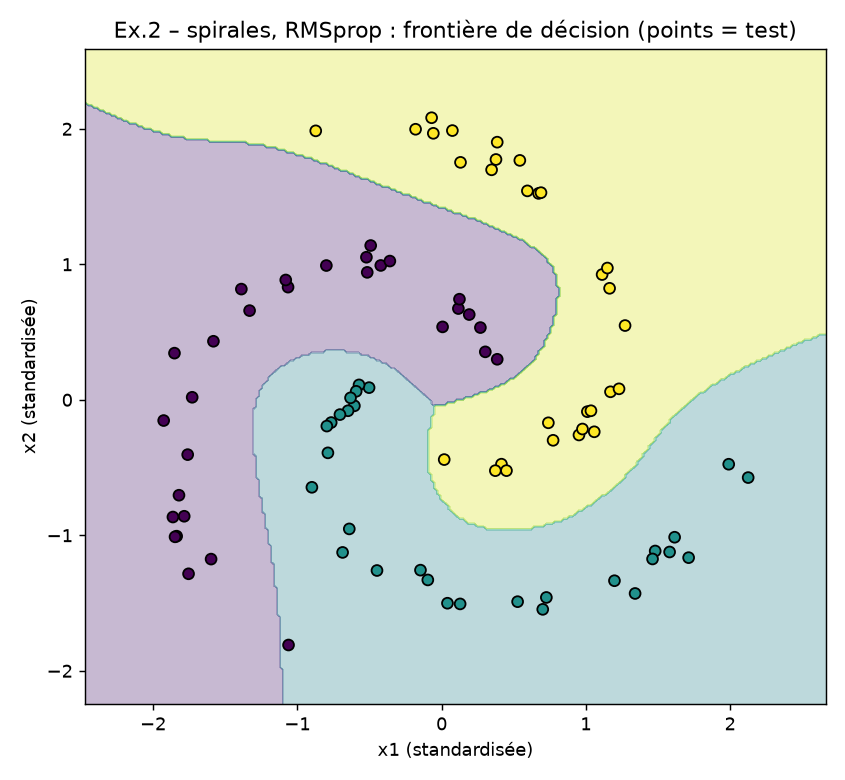

results/figures\ex2_spiral_confusion.png


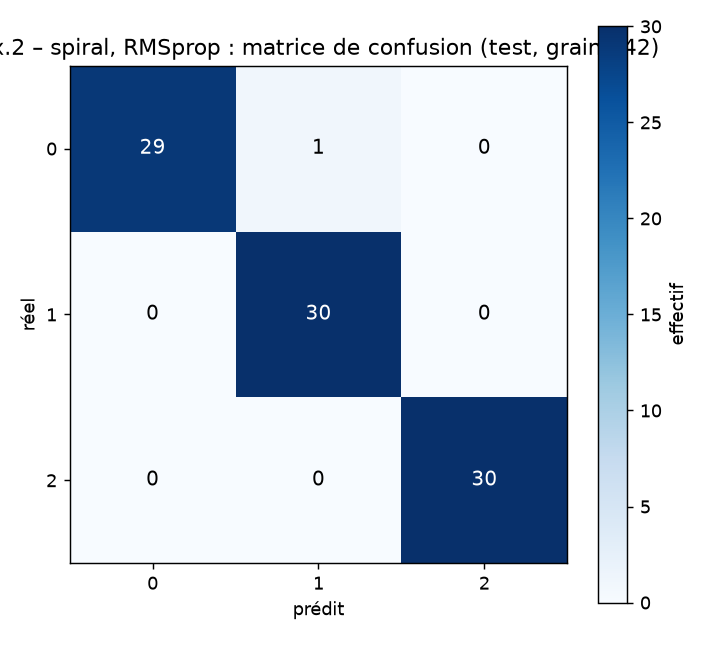

results/figures\ex2_spiral_curves.png


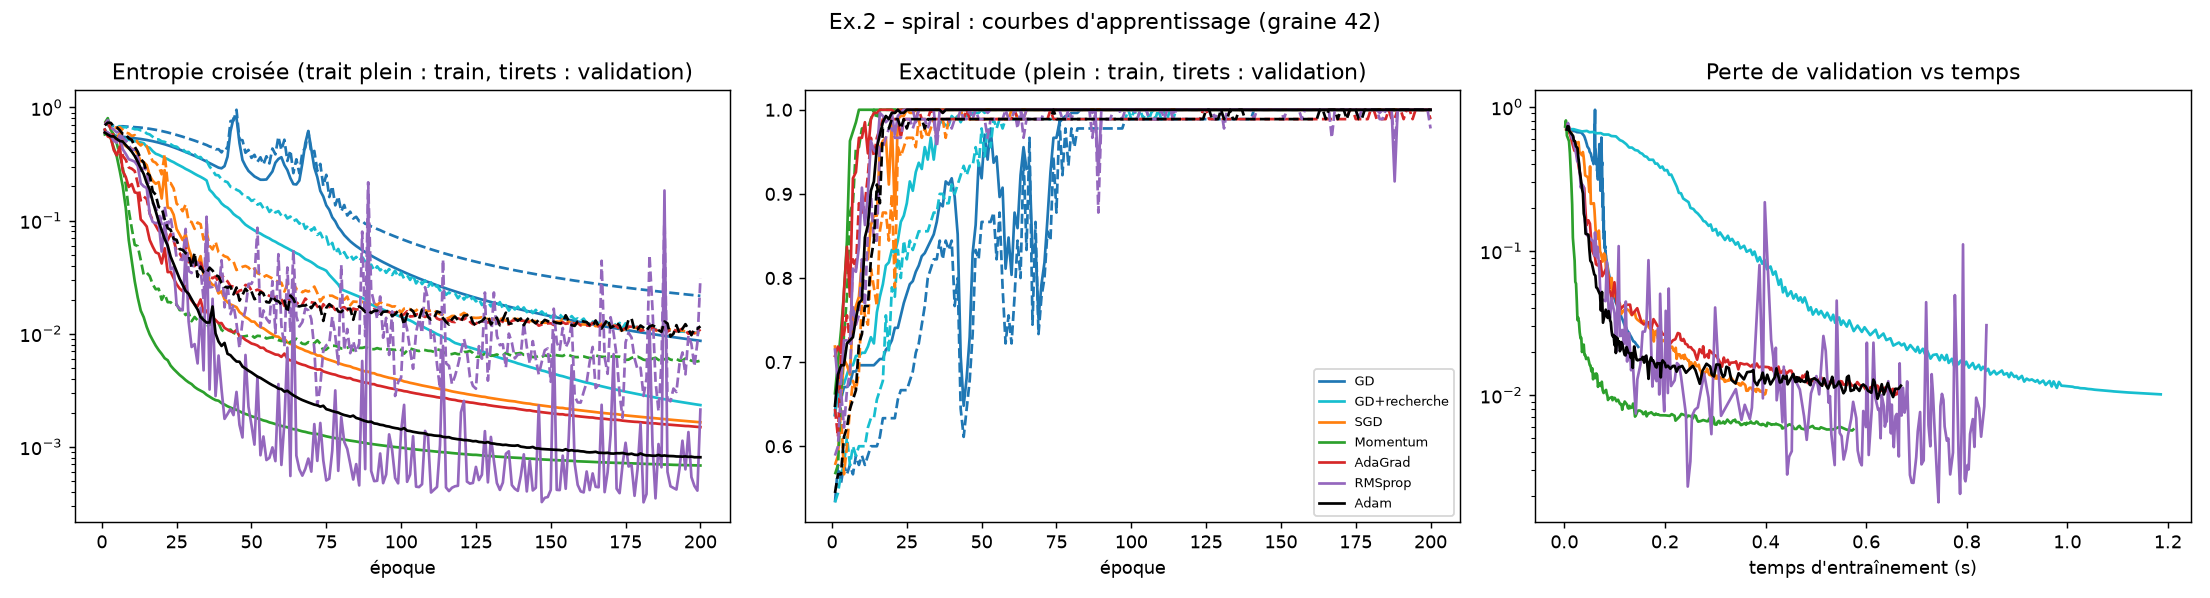

results/figures\ex2_spiral_f1.png


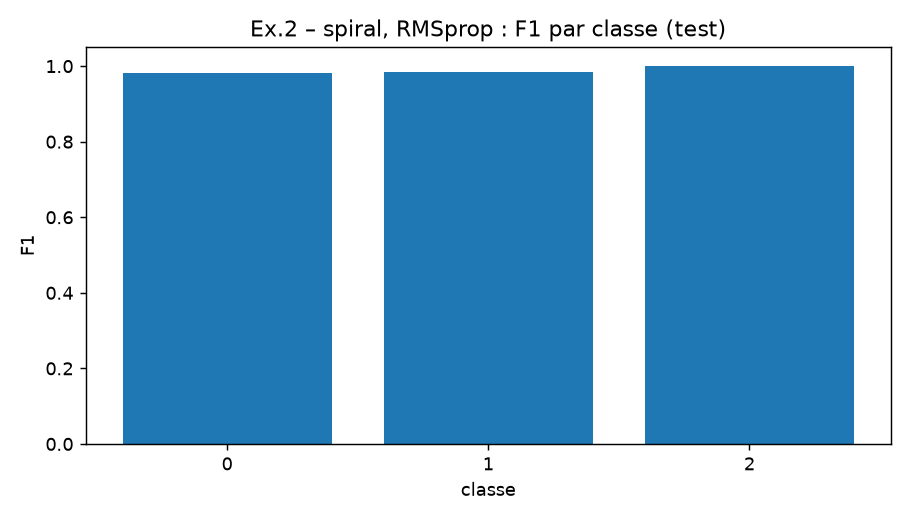

In [ ]:
import glob
from IPython.display import Image, display
for f in sorted(glob.glob("results/figures/ex2_*.png")):
    print(f); display(Image(filename=f, width=900))

## Export

In [ ]:
import shutil, os
shutil.make_archive("results", "zip", "results")
print("Créé :", os.path.abspath("results.zip"), "(%.1f Mo)" % (os.path.getsize("results.zip") / 1e6))

Créé : c:\Users\lenovo\Desktop\HADRI\results.zip (1.5 Mo)
